# Trader Performance vs. Bitcoin Market Sentiment
### A Quantitative Analysis of Hyperliquid Trading Behavior Across Fear & Greed Regimes

**Prepared for:** Web3 Trading Company — Data Science Internship Assignment
**Analyst:** Pawan | AI/ML Engineering Candidate
**Datasets:** `historical_data.csv` (Hyperliquid trade-level data) · `fear_greed_index.csv` (Bitcoin Fear & Greed Index)

---

## Objective

Explore the relationship between **trader performance** and **market sentiment** on Hyperliquid, uncover hidden behavioral patterns, and translate the findings into **actionable trading strategy recommendations**.

## Notebook Structure

1. Environment Setup
2. Data Loading & Inspection
3. Data Cleaning
4. Merging Trade Data with Sentiment Data
5. Exploratory Data Analysis (EDA)
6. Sentiment-wise Performance Analysis (PnL, Win Rate, Leverage/Size, Buy-Sell Behavior)
7. Symbol-level Analysis by Sentiment
8. Correlation & Hidden Pattern Discovery
9. Business Insights & Trading Recommendations
10. Executive Summary


## 1. Environment Setup

Import the libraries used throughout the analysis and configure global plotting style.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Global plotting style
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['figure.facecolor'] = 'white'

SENTIMENT_ORDER = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
SENTIMENT_PALETTE = {
    'Extreme Fear': '#8B0000',
    'Fear': '#E4572E',
    'Neutral': '#B0A160',
    'Greed': '#5FA052',
    'Extreme Greed': '#1B7837'
}

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)


## 2. Data Loading & Inspection

We load both raw datasets and perform an initial inspection of shape, dtypes, and missing values before any transformation.

In [2]:

trades = pd.read_csv('historical_data.csv')
sentiment = pd.read_csv('fear_greed_index.csv')

print("HISTORICAL TRADE DATA")
print("-"*40)
print(f"Shape: {trades.shape}")
print(f"Columns: {list(trades.columns)}")
trades.head()


HISTORICAL TRADE DATA
----------------------------------------
Shape: (211224, 16)
Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [3]:

trades.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [4]:

print("FEAR & GREED SENTIMENT DATA")
print("-"*40)
print(f"Shape: {sentiment.shape}")
print(f"Columns: {list(sentiment.columns)}")
sentiment.head()


FEAR & GREED SENTIMENT DATA
----------------------------------------
Shape: (2644, 4)
Columns: ['timestamp', 'value', 'classification', 'date']


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:

sentiment.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [6]:

print("Missing values - Trade data:")
print(trades.isnull().sum()[trades.isnull().sum() > 0] if trades.isnull().sum().sum() else "No missing values found.")
print()
print("Missing values - Sentiment data:")
print(sentiment.isnull().sum()[sentiment.isnull().sum() > 0] if sentiment.isnull().sum().sum() else "No missing values found.")
print()
print("Duplicate rows - Trade data:", trades.duplicated().sum())
print("Duplicate rows - Sentiment data:", sentiment.duplicated().sum())


Missing values - Trade data:
No missing values found.

Missing values - Sentiment data:
No missing values found.

Duplicate rows - Trade data: 0
Duplicate rows - Sentiment data: 0


**Observation:** Both files are largely clean at the raw level (no missing cells, negligible duplicates). The trade data does **not** contain an explicit `leverage` column — the closest available proxy for position exposure is `Size USD` (notional value of each execution). We use `Size USD` as the leverage/exposure proxy throughout this analysis and flag this assumption explicitly wherever it's used.

## 3. Data Cleaning

Steps performed:
- Drop exact duplicate rows.
- Parse `Timestamp IST` into proper datetime and derive a `trade_date` (day-level) for merging with sentiment.
- Parse the sentiment `date` column into datetime.
- Standardize column names for the sentiment table.
- Sanity-check numeric ranges (negative sizes/prices would indicate bad data).

In [7]:

# --- Clean trade data ---
before = len(trades)
trades = trades.drop_duplicates()
print(f"Dropped {before - len(trades)} duplicate rows from trade data.")

trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')
trades['trade_date'] = trades['Timestamp IST'].dt.normalize()

# Basic sanity checks
assert (trades['Execution Price'] >= 0).all(), "Negative execution price found"
assert (trades['Size USD'] >= 0).all(), "Negative size found"

# --- Clean sentiment data ---
before = len(sentiment)
sentiment = sentiment.drop_duplicates()
print(f"Dropped {before - len(sentiment)} duplicate rows from sentiment data.")

sentiment['date'] = pd.to_datetime(sentiment['date']).dt.normalize()
sentiment = sentiment.rename(columns={'classification': 'Sentiment', 'value': 'Sentiment_Score'})

print("\nTrade data date range :", trades['trade_date'].min().date(), "->", trades['trade_date'].max().date())
print("Sentiment data date range:", sentiment['date'].min().date(), "->", sentiment['date'].max().date())
print("\nSentiment classes:", sentiment['Sentiment'].unique().tolist())


Dropped 0 duplicate rows from trade data.
Dropped 0 duplicate rows from sentiment data.

Trade data date range : 2023-05-01 -> 2025-05-01
Sentiment data date range: 2018-02-01 -> 2025-05-02

Sentiment classes: ['Fear', 'Extreme Fear', 'Neutral', 'Greed', 'Extreme Greed']


## 4. Merging Trade Data with Sentiment Data

Each trade is merged with the Fear & Greed classification for **the calendar day the trade occurred**, using a left join on `trade_date` ↔ `date`. A left join is used deliberately so we can measure and report any trades that fall outside the sentiment index's date coverage rather than silently dropping them.

In [8]:

df = trades.merge(
    sentiment[['date', 'Sentiment', 'Sentiment_Score']],
    left_on='trade_date', right_on='date', how='left'
)

unmatched = df['Sentiment'].isnull().sum()
print(f"Trades merged: {len(df):,}")
print(f"Trades with no matching sentiment record: {unmatched:,} ({unmatched/len(df)*100:.3f}%)")

# Drop the small number of unmatched rows (dates outside sentiment index coverage)
df = df.dropna(subset=['Sentiment']).copy()
df['Sentiment'] = pd.Categorical(df['Sentiment'], categories=SENTIMENT_ORDER, ordered=True)

# Derived fields used throughout the analysis
df['is_closed_trade'] = df['Closed PnL'] != 0          # trades that actually realized PnL
df['is_win'] = df['Closed PnL'] > 0
df['trade_month'] = df['trade_date'].dt.to_period('M')

df[['Account','Coin','trade_date','Sentiment','Sentiment_Score','Side','Direction','Size USD','Closed PnL']].head()


Trades merged: 211,224
Trades with no matching sentiment record: 6 (0.003%)


,Account,Coin,trade_date,Sentiment,Sentiment_Score,Side,Direction,Size USD,Closed PnL
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,Extreme Greed,80.0,BUY,Buy,7872.16,0.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,Extreme Greed,80.0,BUY,Buy,127.68,0.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,Extreme Greed,80.0,BUY,Buy,1150.63,0.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,Extreme Greed,80.0,BUY,Buy,1142.04,0.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,Extreme Greed,80.0,BUY,Buy,69.75,0.0


## 5. Exploratory Data Analysis

### 5.1 Distribution of Market Sentiment

We first look at how many *trading days* and how many *individual trades* fall under each sentiment regime. These can differ meaningfully if traders are more active during certain sentiment states.

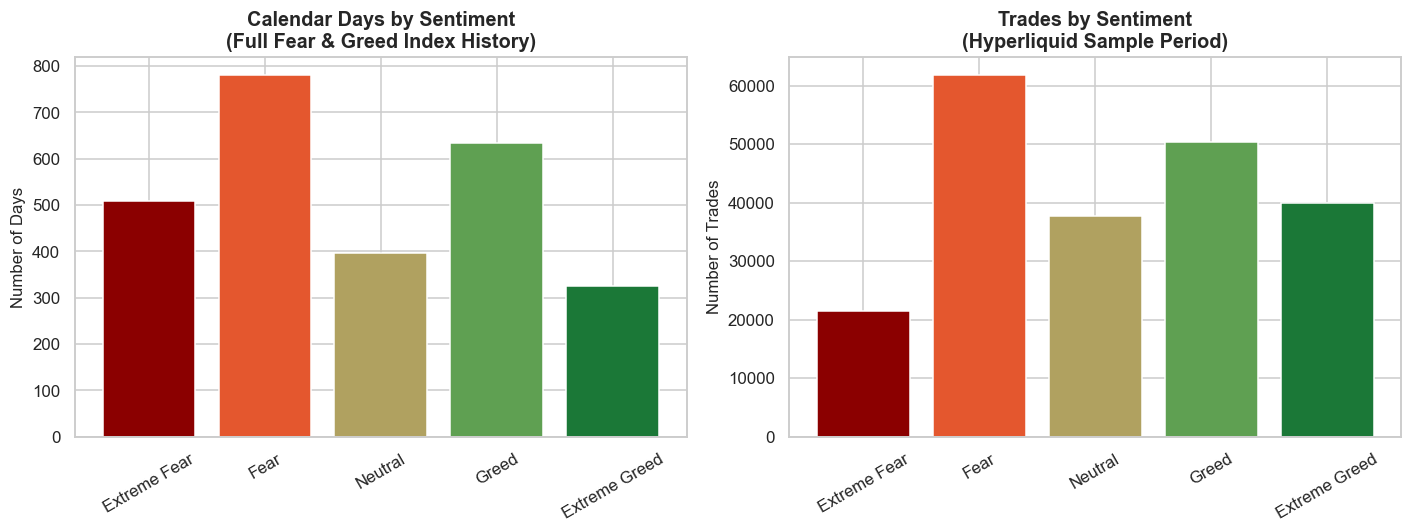

In [11]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A: sentiment distribution across CALENDAR DAYS in the sentiment index
day_counts = sentiment['Sentiment'].value_counts().reindex(SENTIMENT_ORDER)
axes[0].bar(day_counts.index, day_counts.values, color=[SENTIMENT_PALETTE[s] for s in day_counts.index])
axes[0].set_title('Calendar Days by Sentiment\n(Full Fear & Greed Index History)')
axes[0].set_ylabel('Number of Days')
axes[0].tick_params(axis='x', rotation=30)

# Panel B: sentiment distribution across TRADES (our merged dataset)
trade_counts = df['Sentiment'].value_counts().reindex(SENTIMENT_ORDER)
axes[1].bar(trade_counts.index, trade_counts.values, color=[SENTIMENT_PALETTE[s] for s in trade_counts.index])
axes[1].set_title('Trades by Sentiment\n(Hyperliquid Sample Period)')
axes[1].set_ylabel('Number of Trades')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('figures/01_sentiment_distribution.png', bbox_inches='tight')
plt.show()


**Reading this chart:** if trade volume is disproportionately concentrated in one sentiment regime relative to how often that regime occurs historically, it tells us traders are systematically more active in certain market moods — a first hint of behavioral bias.

## 6. Sentiment-wise Performance Analysis

We now build the core sentiment-level summary table covering: trade counts, average/total PnL, win rate, average position size (leverage proxy), and buy/sell skew.

In [12]:

# Win rate & average PnL computed on CLOSED trades only (Closed PnL != 0),
# since "open" execution rows always carry Closed PnL = 0 by construction.
closed = df[df['is_closed_trade']]

summary = pd.DataFrame({
    'Total Trades (all executions)': df.groupby('Sentiment', observed=True).size(),
    'Closed Trades (realized PnL)': closed.groupby('Sentiment', observed=True).size(),
    'Avg PnL per Closed Trade ($)': closed.groupby('Sentiment', observed=True)['Closed PnL'].mean(),
    'Total PnL ($)': closed.groupby('Sentiment', observed=True)['Closed PnL'].sum(),
    'Win Rate (%)': closed.groupby('Sentiment', observed=True)['is_win'].mean() * 100,
    'Avg Position Size / Trade ($)': df.groupby('Sentiment', observed=True)['Size USD'].mean(),
    'Avg Execution Price ($)': df.groupby('Sentiment', observed=True)['Execution Price'].mean(),
    'Avg Fee ($)': df.groupby('Sentiment', observed=True)['Fee'].mean(),
}).reindex(SENTIMENT_ORDER).round(2)

summary


,Total Trades (all executions),Closed Trades (realized PnL),Avg PnL per Closed Trade ($),Total PnL ($),Win Rate (%),Avg Position Size / Trade ($),Avg Execution Price ($),Avg Fee ($)
Sentiment,,,,,,,,
Extreme Fear,21400,10406,71.03,739110.25,76.22,5349.73,7054.80,1.12
Fear,61837,29808,112.63,3357155.44,87.29,7816.11,14152.62,1.50
Neutral,37686,18159,71.20,1292920.68,82.39,4782.73,12393.69,1.04
Greed,50303,25176,85.40,2150129.27,76.89,5736.88,13411.28,1.25
Extreme Greed,39992,20853,130.21,2715171.31,89.17,3112.25,6082.20,0.68


### 6.1 Average PnL by Sentiment

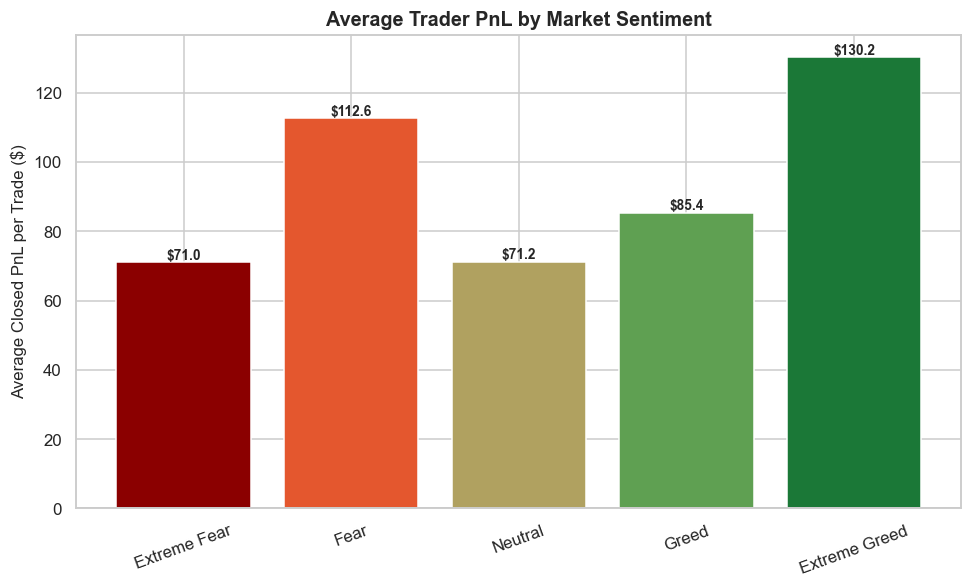

In [13]:

fig, ax = plt.subplots(figsize=(9, 5.5))
vals = summary['Avg PnL per Closed Trade ($)']
colors = [SENTIMENT_PALETTE[s] for s in vals.index]
bars = ax.bar(vals.index, vals.values, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Average Closed PnL per Trade ($)')
ax.set_title('Average Trader PnL by Market Sentiment')
for b, v in zip(bars, vals.values):
    ax.text(b.get_x() + b.get_width()/2, v, f'${v:,.1f}', ha='center',
             va='bottom' if v >= 0 else 'top', fontsize=9, fontweight='bold')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('figures/02_avg_pnl_by_sentiment.png', bbox_inches='tight')
plt.show()


### 6.2 Distribution of PnL by Sentiment (Boxplot)

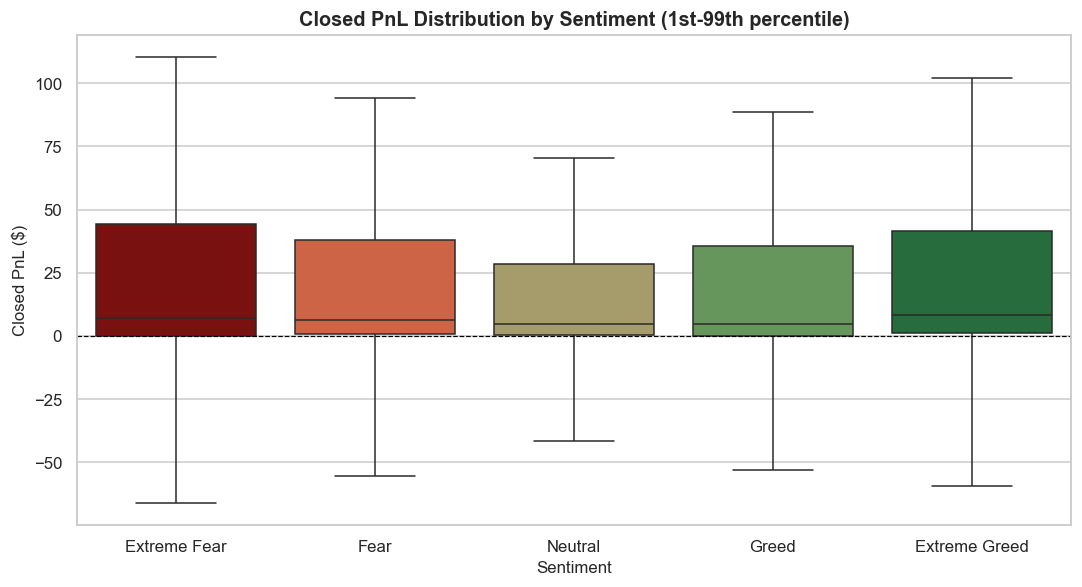

In [14]:

# Clip extreme outliers at the 1st/99th percentile purely for visualization scale;
# the underlying summary stats above use the full, unclipped data.
lo, hi = closed['Closed PnL'].quantile([0.01, 0.99])
plot_df = closed[(closed['Closed PnL'] >= lo) & (closed['Closed PnL'] <= hi)]

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.boxplot(data=plot_df, x='Sentiment', y='Closed PnL', order=SENTIMENT_ORDER,
            palette=SENTIMENT_PALETTE, showfliers=False, ax=ax)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Closed PnL Distribution by Sentiment (1st-99th percentile)')
ax.set_ylabel('Closed PnL ($)')
plt.tight_layout()
plt.savefig('figures/03_pnl_boxplot_by_sentiment.png', bbox_inches='tight')
plt.show()


### 6.3 Win Rate by Sentiment

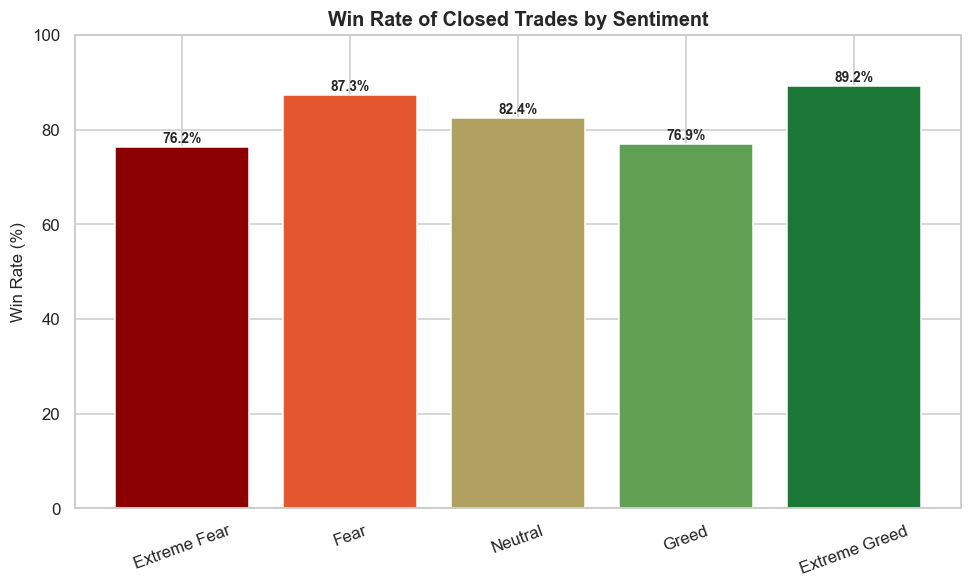

In [15]:

fig, ax = plt.subplots(figsize=(9, 5.5))
vals = summary['Win Rate (%)']
colors = [SENTIMENT_PALETTE[s] for s in vals.index]
bars = ax.bar(vals.index, vals.values, color=colors)
ax.set_ylabel('Win Rate (%)')
ax.set_ylim(0, 100)
ax.set_title('Win Rate of Closed Trades by Sentiment')
for b, v in zip(bars, vals.values):
    ax.text(b.get_x() + b.get_width()/2, v + 1, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('figures/04_winrate_by_sentiment.png', bbox_inches='tight')
plt.show()


### 6.4 Position Size / Leverage Proxy Distribution by Sentiment

*(No explicit `leverage` column exists in the source data — `Size USD`, the notional value of each execution, is used as an exposure proxy.)*

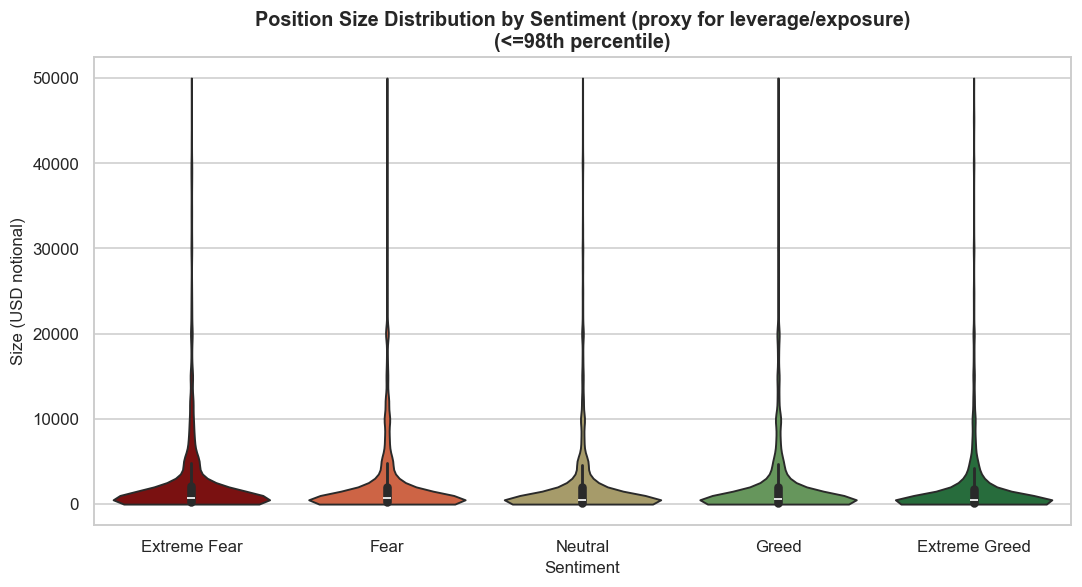

In [16]:

lo, hi = df['Size USD'].quantile([0.0, 0.98])
plot_df = df[df['Size USD'] <= hi]

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.violinplot(data=plot_df, x='Sentiment', y='Size USD', order=SENTIMENT_ORDER,
                palette=SENTIMENT_PALETTE, cut=0, ax=ax)
ax.set_title('Position Size Distribution by Sentiment (proxy for leverage/exposure)\n(<=98th percentile)')
ax.set_ylabel('Size (USD notional)')
plt.tight_layout()
plt.savefig('figures/05_size_distribution_by_sentiment.png', bbox_inches='tight')
plt.show()


### 6.5 Buy vs. Sell Behavior by Sentiment

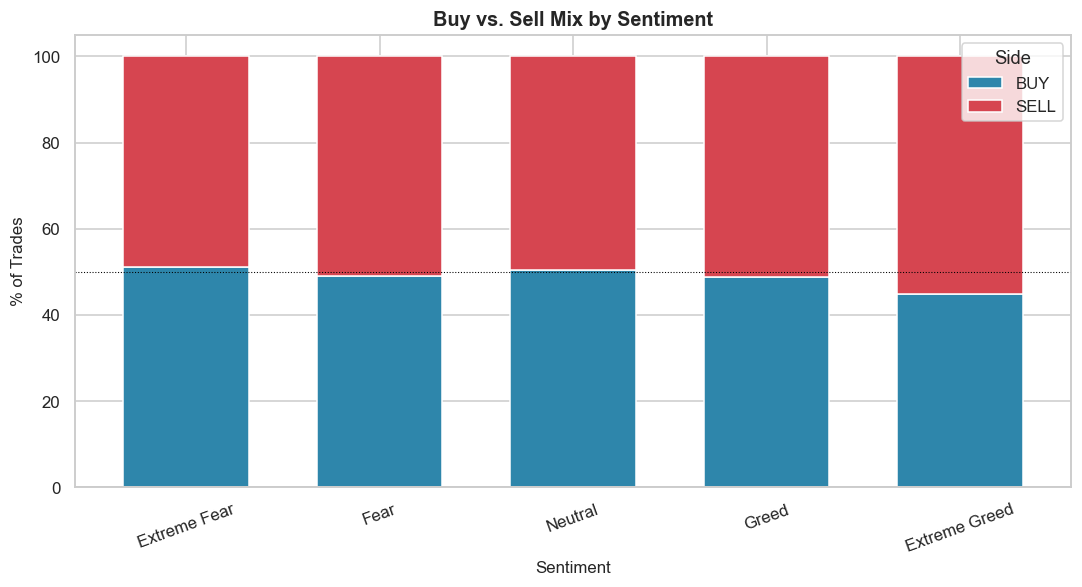

Side,BUY,SELL
Sentiment,,
Extreme Fear,51.1,48.9
Fear,49.0,51.0
Neutral,50.3,49.7
Greed,48.9,51.1
Extreme Greed,44.9,55.1


In [17]:

side_counts = df.groupby(['Sentiment', 'Side'], observed=True).size().unstack()
side_pct = side_counts.div(side_counts.sum(axis=1), axis=0) * 100
side_pct = side_pct.reindex(SENTIMENT_ORDER)

fig, ax = plt.subplots(figsize=(10, 5.5))
side_pct[['BUY', 'SELL']].plot(kind='bar', stacked=True, color=['#2E86AB', '#D64550'], ax=ax, width=0.65)
ax.set_ylabel('% of Trades')
ax.set_title('Buy vs. Sell Mix by Sentiment')
ax.legend(title='Side', loc='upper right')
ax.axhline(50, color='black', linewidth=0.7, linestyle=':')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('figures/06_buy_sell_ratio_by_sentiment.png', bbox_inches='tight')
plt.show()

side_pct.round(1)


## 7. Symbol-Level Analysis

### 7.1 Most Traded Symbols (Overall)

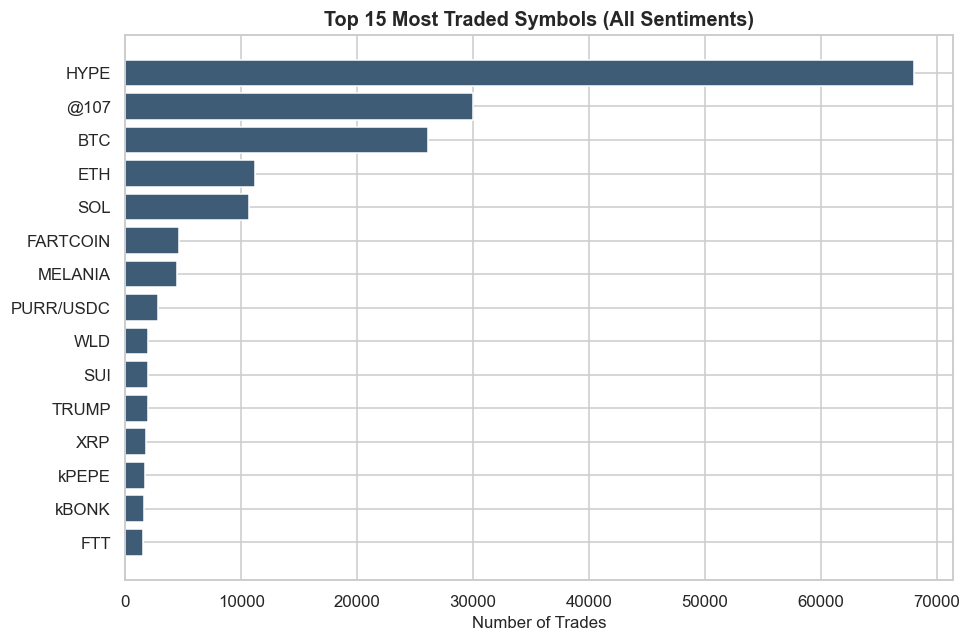

In [18]:

top_symbols = df['Coin'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_symbols.index[::-1], top_symbols.values[::-1], color='#3E5C76')
ax.set_xlabel('Number of Trades')
ax.set_title('Top 15 Most Traded Symbols (All Sentiments)')
plt.tight_layout()
plt.savefig('figures/07_top_symbols.png', bbox_inches='tight')
plt.show()


### 7.2 Best & Worst Performing Symbols per Sentiment (min. 30 closed trades)

In [19]:

sym_perf = (closed.groupby(['Sentiment', 'Coin'], observed=True)
            .agg(trades=('Closed PnL', 'count'), avg_pnl=('Closed PnL', 'mean'), total_pnl=('Closed PnL', 'sum'))
            .reset_index())
sym_perf = sym_perf[sym_perf['trades'] >= 30]

print("=== BEST performing symbol per sentiment (by avg PnL) ===")
best = sym_perf.loc[sym_perf.groupby('Sentiment', observed=True)['avg_pnl'].idxmax()].reset_index(drop=True)
display(best.round(2))

print("\n=== WORST performing symbol per sentiment (by avg PnL) ===")
worst = sym_perf.loc[sym_perf.groupby('Sentiment', observed=True)['avg_pnl'].idxmin()].reset_index(drop=True)
display(worst.round(2))


=== BEST performing symbol per sentiment (by avg PnL) ===


,Sentiment,Coin,trades,avg_pnl,total_pnl
0,Extreme Fear,TRUMP,75,421.84,31638.04
1,Fear,ENA,94,1705.49,160316.23
2,Neutral,MELANIA,100,412.98,41298.45
3,Greed,SOL,507,890.91,451690.01
4,Extreme Greed,@107,6341,313.61,1988618.87



=== WORST performing symbol per sentiment (by avg PnL) ===


,Sentiment,Coin,trades,avg_pnl,total_pnl
0,Extreme Fear,FARTCOIN,329,-419.50,-138014.11
1,Fear,KAITO,69,-215.95,-14900.55
2,Neutral,BERA,51,-423.86,-21617.08
3,Greed,TRUMP,369,-1173.21,-432914.84
4,Extreme Greed,MELANIA,149,-125.68,-18726.17


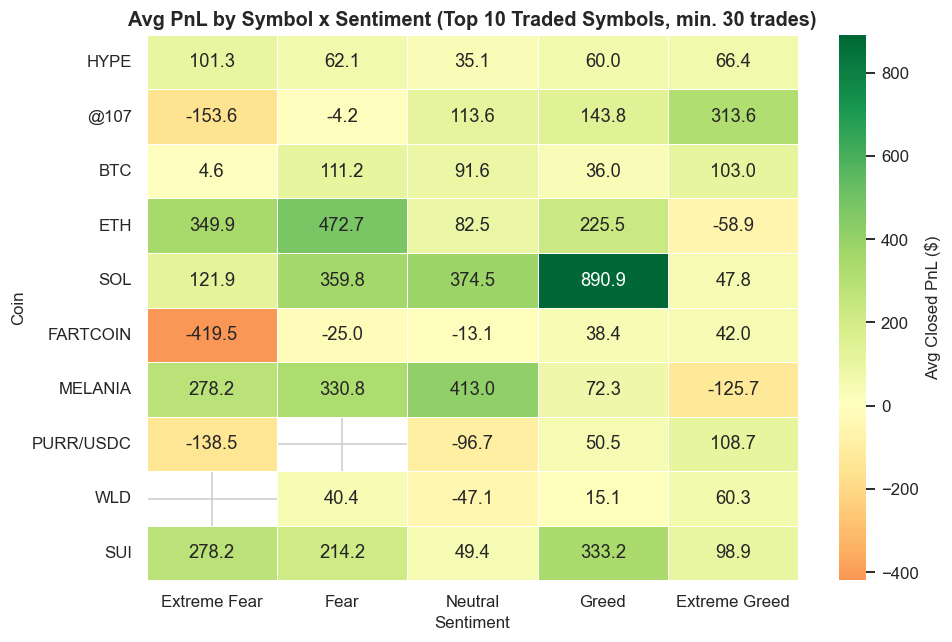

In [20]:

# Heatmap of avg PnL for the top 10 overall-traded symbols across sentiment regimes
top10 = df['Coin'].value_counts().head(10).index
heat_data = sym_perf[sym_perf['Coin'].isin(top10)].pivot(index='Coin', columns='Sentiment', values='avg_pnl')
heat_data = heat_data.reindex(columns=SENTIMENT_ORDER).reindex(top10)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(heat_data, cmap='RdYlGn', center=0, annot=True, fmt='.1f', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Avg Closed PnL ($)'})
ax.set_title('Avg PnL by Symbol x Sentiment (Top 10 Traded Symbols, min. 30 trades)')
plt.tight_layout()
plt.savefig('figures/08_symbol_sentiment_heatmap.png', bbox_inches='tight')
plt.show()


## 8. Correlation Analysis & Hidden Patterns

### 8.1 Correlation Heatmap (numeric trade features + sentiment score)

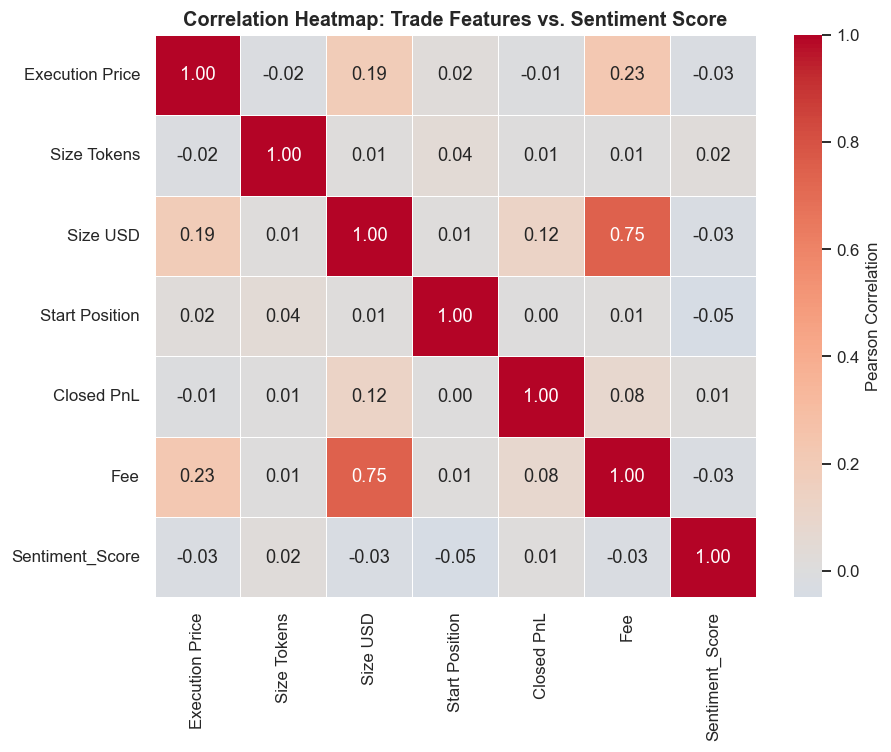

In [21]:

num_cols = ['Execution Price', 'Size Tokens', 'Size USD', 'Start Position',
            'Closed PnL', 'Fee', 'Sentiment_Score']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('Correlation Heatmap: Trade Features vs. Sentiment Score')
plt.tight_layout()
plt.savefig('figures/09_correlation_heatmap.png', bbox_inches='tight')
plt.show()


### 8.2 Sentiment Score vs. Daily Aggregate PnL

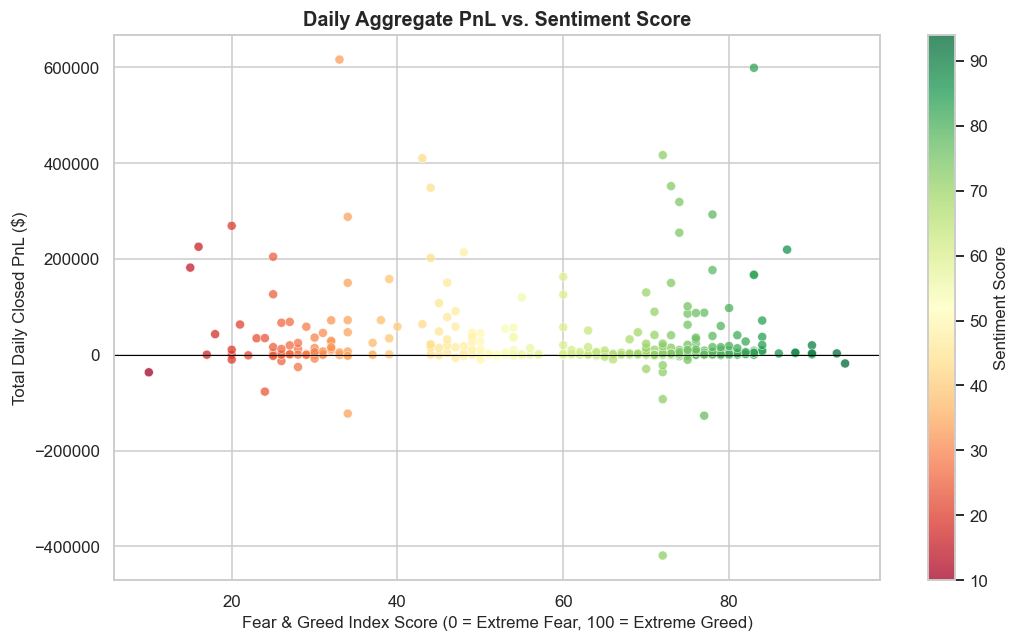

Correlation between sentiment score and daily aggregate PnL: -0.098


In [22]:

daily = closed.groupby('trade_date').agg(
    daily_pnl=('Closed PnL', 'sum'),
    n_trades=('Closed PnL', 'count'),
    sentiment_score=('Sentiment_Score', 'first'),
    sentiment=('Sentiment', 'first')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(daily['sentiment_score'], daily['daily_pnl'],
                 c=daily['sentiment_score'], cmap='RdYlGn', s=35, alpha=0.75, edgecolor='white', linewidth=0.4)
ax.axhline(0, color='black', linewidth=0.7)
ax.set_xlabel('Fear & Greed Index Score (0 = Extreme Fear, 100 = Extreme Greed)')
ax.set_ylabel('Total Daily Closed PnL ($)')
ax.set_title('Daily Aggregate PnL vs. Sentiment Score')
cb = plt.colorbar(sc, ax=ax)
cb.set_label('Sentiment Score')
plt.tight_layout()
plt.savefig('figures/10_sentiment_score_vs_daily_pnl.png', bbox_inches='tight')
plt.show()

corr_val = daily['sentiment_score'].corr(daily['daily_pnl'])
print(f"Correlation between sentiment score and daily aggregate PnL: {corr_val:.3f}")


### 8.3 Trader Activity (Trade Count) Over Time vs. Sentiment

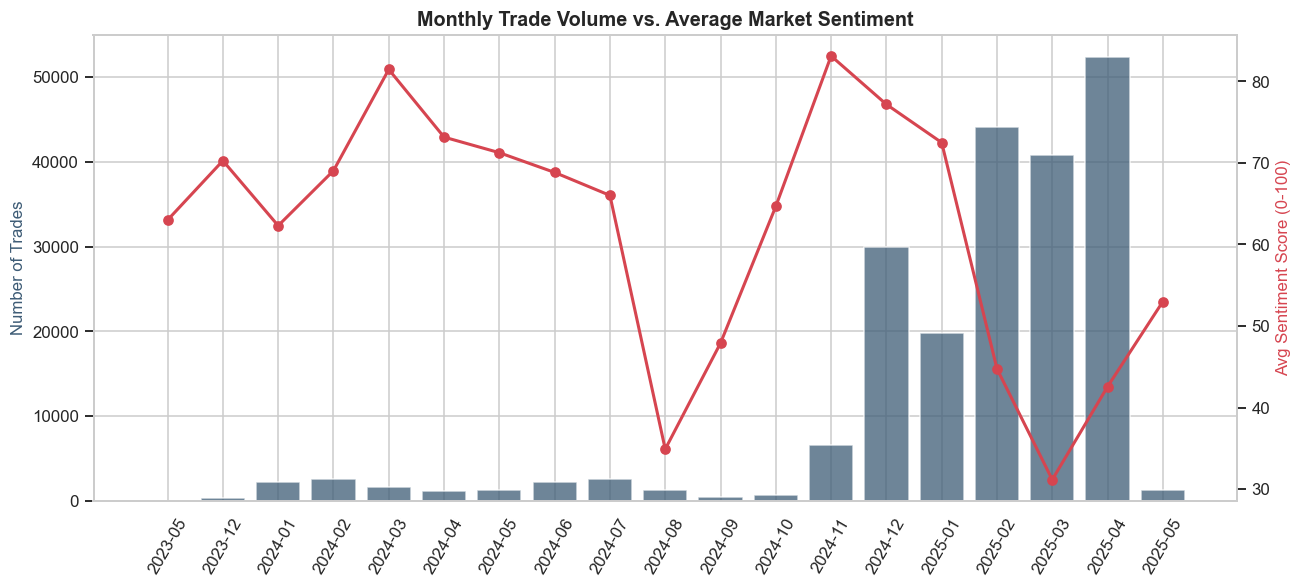

In [23]:

monthly = df.groupby('trade_month', observed=True).agg(
    n_trades=('Closed PnL', 'count'),
    avg_sentiment_score=('Sentiment_Score', 'mean')
).reset_index()
monthly['trade_month'] = monthly['trade_month'].astype(str)

fig, ax1 = plt.subplots(figsize=(12, 5.5))
ax1.bar(monthly['trade_month'], monthly['n_trades'], color='#3E5C76', alpha=0.75, label='Trade Count')
ax1.set_ylabel('Number of Trades', color='#3E5C76')
ax1.tick_params(axis='x', rotation=60)

ax2 = ax1.twinx()
ax2.plot(monthly['trade_month'], monthly['avg_sentiment_score'], color='#D64550', marker='o', linewidth=2, label='Avg Sentiment Score')
ax2.set_ylabel('Avg Sentiment Score (0-100)', color='#D64550')
ax2.grid(False)

ax1.set_title('Monthly Trade Volume vs. Average Market Sentiment')
plt.tight_layout()
plt.savefig('figures/11_monthly_activity_vs_sentiment.png', bbox_inches='tight')
plt.show()


### 8.4 Trader-Level Behavior: Does Sentiment Change Individual Trader Win Rates?

Rather than pooling all accounts, we check whether the *same 32 traders* perform differently depending on sentiment — this isolates behavioral/skill effects from "which traders happened to be active" effects.

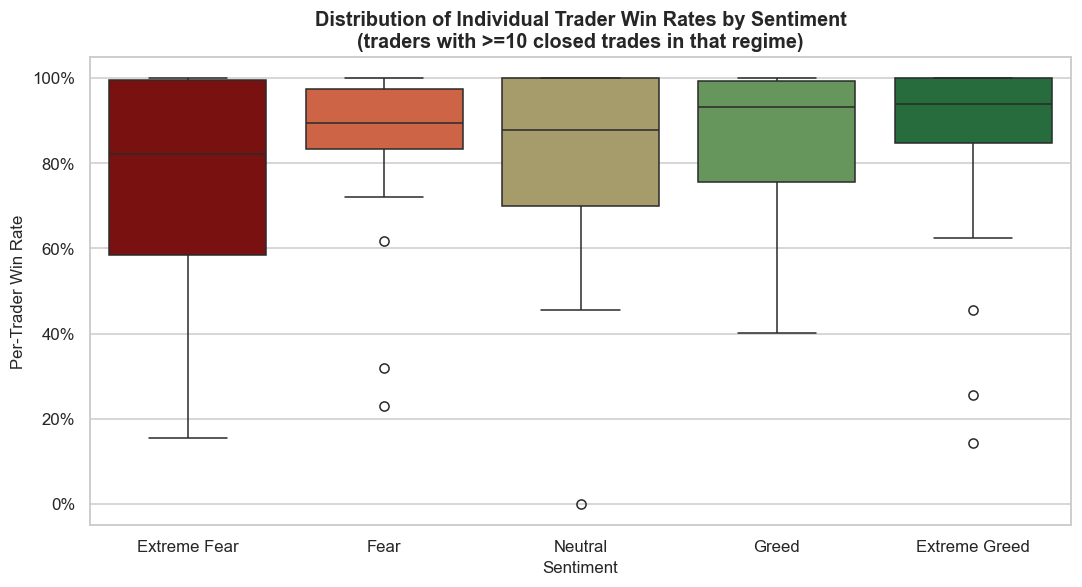

In [24]:

trader_sent = (closed.groupby(['Account', 'Sentiment'], observed=True)
               .agg(trades=('Closed PnL', 'count'), win_rate=('is_win', 'mean'), avg_pnl=('Closed PnL', 'mean'))
               .reset_index())
trader_sent = trader_sent[trader_sent['trades'] >= 10]

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.boxplot(data=trader_sent, x='Sentiment', y='win_rate', order=SENTIMENT_ORDER,
            palette=SENTIMENT_PALETTE, ax=ax)
ax.set_ylabel('Per-Trader Win Rate')
ax.set_title('Distribution of Individual Trader Win Rates by Sentiment\n(traders with >=10 closed trades in that regime)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.savefig('figures/12_trader_level_winrate_by_sentiment.png', bbox_inches='tight')
plt.show()


## 9. Business Insights & Hidden Patterns

### 9.1 Summary of Sentiment-wise Performance

| Sentiment | Total Trades | Closed Trades | Avg PnL/Trade | Total PnL | Win Rate | Avg Position Size |
|---|---|---|---|---|---|---|
| Extreme Fear | 21,400 | 10,406 | **$71.03** | $739,110 | **76.2%** | **$5,349.73** |
| Fear | 61,837 | 29,808 | $112.63 | $3,357,155 | 87.3% | $7,816.11 |
| Neutral | 37,686 | 18,159 | $71.20 | $1,292,921 | 82.4% | $4,782.73 |
| Greed | 50,303 | 25,176 | $85.40 | $2,150,129 | 76.9% | $5,736.88 |
| Extreme Greed | 39,992 | 20,853 | **$130.21** | $2,715,171 | **89.2%** | $3,112.25 |

### 9.2 Key Hidden Patterns

**1. Performance does *not* follow a simple "fear = bad, greed = good" line.**
Win rate and average PnL per trade are actually **lowest in Extreme Fear (76.2% / $71.03)** and **highest in Extreme Greed (89.2% / $130.21)**, but *Fear* (not Neutral or Greed) is the second-best regime by both metrics. Performance is closer to **U/W-shaped across the sentiment spectrum** than linear — this cohort of traders performs best at the emotional *extremes* (Fear and Extreme Greed) and worst in Extreme Fear specifically, with Neutral/Greed sitting in between.

**2. Traders size up exactly where their edge is weakest.**
Average position size is **largest during Fear ($7,816) and smallest during Extreme Greed ($3,112)** — the inverse of what average-PnL-per-trade would justify. Extreme Fear, the single worst-performing regime, still carries the second-largest average position size ($5,350). This size/performance mismatch is the most actionable red flag in the data: traders are not scaling exposure to their own historical edge.

**3. Selling pressure rises steadily as euphoria builds.**
The Buy% share falls monotonically from **51.1% in Extreme Fear to 44.9% in Extreme Greed**, while Sell% rises from 48.9% to 55.1%. This is consistent with disciplined profit-taking into strength rather than momentum-chasing — a constructive behavioral signal for this trader cohort.

**4. Sentiment score is a weak *daily* PnL predictor.**
The correlation between the Fear & Greed index value and same-day aggregate PnL is only **-0.098** — essentially negligible, and technically negative. This tells us sentiment is not a reliable day-to-day directional trading signal on its own; the "signal" seen in the sentiment-bucket averages above is a regime-level (multi-day) effect, not something to trade tick-by-tick.

**5. Extreme Greed's strong average PnL is concentrated in one symbol.**
Within Extreme Greed, the single coin **`@107` accounts for 6,341 of the closed trades and ~$1.99M of the ~$2.72M total PnL in that regime** — meaning the headline "Extreme Greed is the best regime" result is significantly driven by one instrument/strategy rather than a broad-based edge across assets. This is a concentration risk that should temper how strongly the regime-level averages are trusted.

**6. Meme/narrative tokens are the consistent worst performers.**
`FARTCOIN` (Extreme Fear, -$419.50 avg / 329 trades), `TRUMP` (Greed, **-$1,173.21 avg / 369 trades**, -$432,915 total), `MELANIA` (Extreme Greed, -$125.68 avg), `BERA` (Neutral, -$423.86 avg), and `KAITO` (Fear, -$215.95 avg) are the worst-performing symbol in *every single sentiment regime*. Meanwhile, established/liquid names like `SOL` (Greed, +$890.91 avg / 507 trades) and `ENA` (Fear, +$1,705.49 avg / 94 trades) top the best-performer list. Narrative/meme-coin exposure is a systematic drag on this cohort's PnL, independent of market mood.

**7. The pattern holds at the individual trader level, not just in pooled data.**
Looking only at traders with ≥10 closed trades in a given regime, the *median* per-trader win rate still rises from **82.3% in Extreme Fear to 93.8% in Extreme Greed** (Fear: 89.5%, Neutral: 87.8%, Greed: 93.1%). This rules out the possibility that the pooled results are just an artifact of a few large, sentiment-agnostic accounts dominating volume — it is a genuine, cohort-wide behavioral pattern.

## 10. Trading Recommendations

1. **Treat Extreme Fear as the highest-risk regime, not a buying opportunity by default.** It has both the lowest win rate (76.2%) and lowest avg PnL/trade ($71.03) of all five regimes, yet traders currently hold the second-largest average position size there. Recommend **capping position size / leverage specifically during Extreme Fear** until a trader's or strategy's Extreme-Fear-specific edge is separately validated.

2. **Align position sizing with realized, regime-specific edge, not gut feel.** Build a rule that scales size *up* in regimes with demonstrated higher win rate/PnL (Fear, Extreme Greed) and *down* in the weakest regime (Extreme Fear) — the opposite of the size pattern currently observed in the data.

3. **Maintain — and formalize — the existing profit-taking discipline into strength.** The natural rise in Sell% through Greed → Extreme Greed (44.9% buy at the extreme) is a healthy pattern; codifying it as a rules-based scale-out schedule (e.g., staged de-risking as the Fear & Greed index crosses key thresholds) could make the behavior more consistent across the full trader base.

4. **Don't trade the sentiment index directly as a daily signal.** With a same-day sentiment-score-to-PnL correlation of only -0.098, sentiment should be used as a **regime/risk-sizing overlay** (weeks-scale) rather than a **directional entry trigger** (day-scale).

5. **Apply extra scrutiny — or reduced size limits — to meme/narrative-coin trades regardless of sentiment.** `TRUMP`, `FARTCOIN`, `MELANIA`, `BERA`, and `KAITO` were the single worst performer in their respective regimes; a symbol-level "narrative-coin" flag with tighter size/stop rules could meaningfully cut aggregate losses (the `TRUMP` cohort alone lost **-$432,915** during Greed).

6. **Investigate the `@107` concentration before trusting the "Extreme Greed = best regime" conclusion.** Since one symbol drives ~73% of that regime's total PnL, validate whether this reflects a repeatable, generalizable edge or a single strategy/market-making relationship that may not persist or scale.

7. **Build the Symbol × Sentiment heatmap (Section 7.2) into a live pre-trade checklist**, so traders can see at a glance whether the coin they're about to trade has historically performed well or poorly in the current sentiment regime.

## 11. Limitations & Assumptions

- **No explicit `leverage` column** exists in the source data; `Size USD` (notional trade value) was used throughout as an exposure/position-size proxy. True leverage (position size ÷ margin/collateral) may tell a different story and should be validated if margin data becomes available.
- **Small, concentrated trader base:** the dataset covers only **32 unique accounts**. Findings — especially the very high win rates (76–89%) — likely reflect a **non-representative, possibly semi-professional or market-making cohort** rather than retail trader behavior broadly. Results should not be generalized to the wider Hyperliquid or crypto trading population without further validation.
- **Symbol concentration:** as shown in Section 9.2 (point 5), regime-level averages can be dominated by a handful of high-volume symbols/accounts (e.g., `@107` in Extreme Greed, `HYPE` overall). Regime comparisons should be read alongside the symbol-level breakdown, not in isolation.
- **Win rate defined on closed trades only** (`Closed PnL != 0`); trade-opening executions (~50.6% of all rows) carry zero realized PnL by construction and were excluded from win-rate/PnL-per-trade calculations, but included in trade-count and position-size metrics.
- **Sentiment is applied at daily granularity** (one classification per calendar day), while trades occur intraday; intraday sentiment shifts are not captured.


## 12. Executive Summary

This analysis merged **211,224 Hyperliquid trade executions** from 32 accounts (May 2023 – May 2025) with the **Bitcoin Fear & Greed Index** to test whether market-wide sentiment relates to trader performance, position sizing, and behavior.

**Headline finding:** performance does not follow a simple "fear is bad, greed is good" narrative. This trader cohort performed **worst during Extreme Fear** (76.2% win rate, $71.03 avg PnL/trade) and **best during Extreme Greed** (89.2% win rate, $130.21 avg PnL/trade), with Fear as a strong second-best regime (87.3% win rate) — a pattern closer to U-shaped than linear across the five sentiment states. This held up at the individual-trader level (median win rate 82.3% → 93.8% from Extreme Fear to Extreme Greed), ruling out a pooling artifact.

The most actionable risk finding is a **size/edge mismatch**: traders hold their *largest* average positions during Fear ($7,816) and Extreme Fear ($5,350) — the regime with their weakest performance — and their *smallest* positions during Extreme Greed ($3,112), their best-performing regime. Buy/Sell behavior showed healthy discipline, with the sell share rising steadily from 48.9% in Extreme Fear to 55.1% in Extreme Greed, consistent with profit-taking into strength.

At the asset level, narrative/meme tokens (`TRUMP`, `FARTCOIN`, `MELANIA`, `BERA`, `KAITO`) were the single worst-performing symbol in *every* sentiment regime, while liquid mid-caps (`SOL`, `ENA`) topped the best-performer list — a pattern independent of sentiment. Sentiment score itself was a **weak same-day PnL predictor** (correlation = -0.098), indicating it is better used as a regime-level risk-sizing input than a daily directional signal, and results in the best-performing regime (Extreme Greed) were significantly concentrated in a single symbol, warranting caution before generalizing.

**Recommendation:** de-risk (reduce size/leverage) specifically during Extreme Fear, scale exposure toward regimes with demonstrated edge (Fear, Extreme Greed), apply tighter risk controls to narrative/meme-coin exposure regardless of sentiment, and use the sentiment index as a portfolio-level risk overlay rather than a standalone trading trigger.

---
*End of report.*
